In [3]:
import h5py
import cv2
import numpy as np
import os
import glob
import sys
import json
from PIL import Image
import matplotlib.pyplot as plt
import logging

sys.path.append("../../../../donut/src/test/")
from common.config import cfg

In [2]:
logging.basicConfig(
    filename="./logs/ImageTransformation(test).log",
    encoding="utf-8",
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO,
)

In [3]:
print(cfg.line)
print(cfg.__dict__["0"]) 

3
dot


In [4]:
target_size=(cfg.image_width,cfg.image_height)

target_size

(640, 640)

In [5]:
# list all image paths
image_dir = "../../../data/image_resize/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60575
['../../../data/image_resize/images/45df1fe3293b.jpg', '../../../data/image_resize/images/b2ab3b743d4e.jpg', '../../../data/image_resize/images/51d3b1a6baf3.jpg', '../../../data/image_resize/images/a9e9ce9277c1.jpg', '../../../data/image_resize/images/7f1f545fe081.jpg']


In [6]:
# list all annotation files paths

annotations_dir="../../../data/image_resize/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60575
['../../../data/image_resize/annotations/e91e28111e86.json', '../../../data/image_resize/annotations/75c0449f6917.json', '../../../data/image_resize/annotations/66dd2a250237.json', '../../../data/image_resize/annotations/58595c30beab.json', '../../../data/image_resize/annotations/497a547454d7.json']


In [5]:
# count the total image types

chart_types = set()
for annotation_pth in annotations_files:
    with open(annotation_pth,"r") as f:
        annottation=json.load(f)
        label=annottation["chart-type"]
        chart_types.add(label)

print(chart_types)

{'line', 'vertical_bar', 'dot', 'scatter', 'horizontal_bar'}


In [7]:
# label mapping

label_encoder = {
    "dot": cfg.dot,
    "scatter": cfg.scatter,
    "horizontal_bar": cfg.horizontal_bar,
    "line": cfg.line,
    "vertical_bar": cfg.vertical_bar,
}

print(label_encoder)

{'dot': 0, 'scatter': 1, 'horizontal_bar': 2, 'line': 3, 'vertical_bar': 4}


In [8]:
images=image_files[:5]

In [9]:
images

['../../../data/image_resize/images/45df1fe3293b.jpg',
 '../../../data/image_resize/images/b2ab3b743d4e.jpg',
 '../../../data/image_resize/images/51d3b1a6baf3.jpg',
 '../../../data/image_resize/images/a9e9ce9277c1.jpg',
 '../../../data/image_resize/images/7f1f545fe081.jpg']

In [10]:
annotations=[]
for idx in range(len(images)):
    img_path=images[idx]
    image_id=img_path.split('/')[-1].split('.')[0]
    anno_path = [file for file in annotations_files if image_id in file]
    annotations.append(anno_path[0])

In [11]:
annotations

['../../../data/image_resize/annotations/45df1fe3293b.json',
 '../../../data/image_resize/annotations/b2ab3b743d4e.json',
 '../../../data/image_resize/annotations/51d3b1a6baf3.json',
 '../../../data/image_resize/annotations/a9e9ce9277c1.json',
 '../../../data/image_resize/annotations/7f1f545fe081.json']

In [12]:
num_images = len(images)

num_images

5

In [13]:
output_hdf5 = "./temp/ImageTransformationTest.h5"

In [14]:
with h5py.File(output_hdf5, "w") as hf:
    images_ds = hf.create_dataset("images", (num_images, cfg.image_width, cfg.image_height, 3), dtype=np.uint8)
    labels_ds = hf.create_dataset("labels", (num_images,), dtype=np.int32)

    for i, images_pth in enumerate(images):
        image_id=images_pth.split('/')[-1].split('.')[0]
        image = cv2.imread(images_pth)
        images_ds[i] = image

        anno_path = [file for file in annotations_files if image_id in file]
        with open(anno_path[0],"r") as f:
            annottation=json.load(f)
            labels_ds[i]=label_encoder[annottation["chart-type"]]
        
        logging.info(f"HDF5 complete: {image_id}")

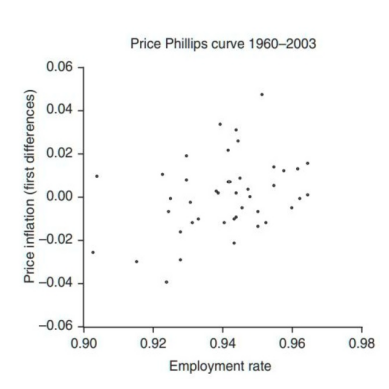

Label: 1
scatter


In [16]:
with h5py.File(output_hdf5, "r") as hf:
    image = hf["images"][2]
    label = hf["labels"][2]  

plt.imshow(image)  
plt.axis("off")  
plt.show()
print(f"Label: {label}")
print(cfg.__dict__[str(label)])

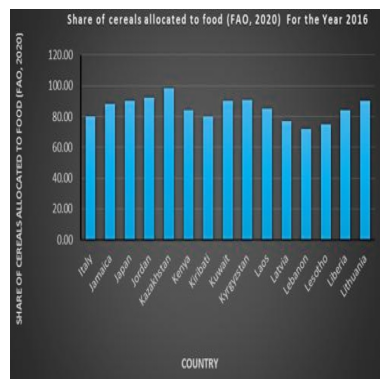

Label: 4
vertical_bar


In [17]:
with h5py.File(output_hdf5, "r") as hf:
    image = hf["images"][1]  
    label = hf["labels"][1] 

plt.imshow(image) 
plt.axis("off")  
plt.show()
print(f"Label: {label}")
print(cfg.__dict__[str(label)])

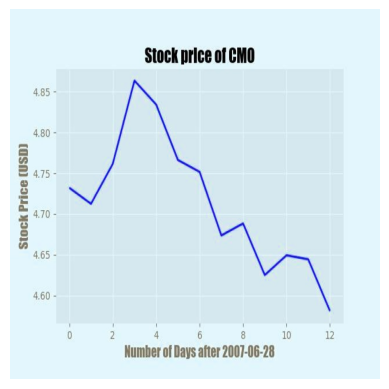

Label: 3
line


In [18]:
with h5py.File(output_hdf5, "r") as hf:
    image = hf["images"][3]  
    label = hf["labels"][3] 

plt.imshow(image) 
plt.axis("off")  
plt.show()
print(f"Label: {label}")
print(cfg.__dict__[str(label)])

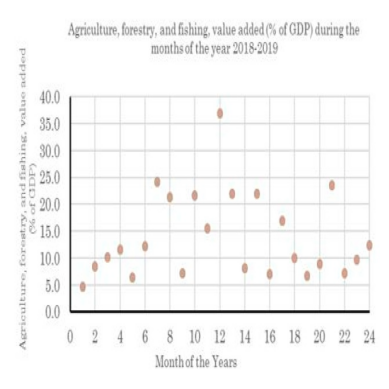

Label: 1
scatter


In [19]:
with h5py.File(output_hdf5, "r") as hf:
    image = hf["images"][0]  
    label = hf["labels"][0] 

plt.imshow(image) 
plt.axis("off")  
plt.show()
print(f"Label: {label}")
print(cfg.__dict__[str(label)])

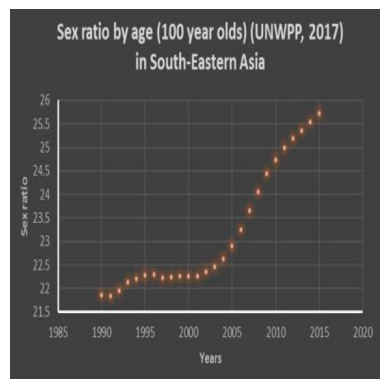

Label: 1
scatter


In [20]:
with h5py.File(output_hdf5, "r") as hf:
    image = hf["images"][4]  
    label = hf["labels"][4] 

plt.imshow(image) 
plt.axis("off")  
plt.show()
print(f"Label: {label}")
print(cfg.__dict__[str(label)])